# Daily Challenge: NumPy, Pandas, and Matplotlib Integration



In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3
Matplotlib version: 3.10.7


## Task 1: Data Preparation



In [3]:
np.random.seed(42)

# Generating synthetic temperature data for 10 cities across 12 months
# Temperature range: -5 to 35 degrees Celsius
n_cities = 10
n_months = 12

# Using np.random.uniform to generate temperature data
temperature_data = np.random.uniform(low=-5, high=35, size=(n_cities, n_months))

print("Temperature data generated using NumPy:")
print(f"Shape: {temperature_data.shape}")
print(f"Data type: {temperature_data.dtype}")
print(f"Temperature range: {temperature_data.min():.2f}°C to {temperature_data.max():.2f}°C")


print("\nFirst 5 cities, first 6 months (preview):")
print(temperature_data[:5, :6])

Temperature data generated using NumPy:
Shape: (10, 12)
Data type: float64
Temperature range: -4.78°C to 34.48°C

First 5 cities, first 6 months (preview):
[[ 9.98160475 33.02857226 24.27975767 18.94633937  1.24074562  1.23978081]
 [28.29770563  3.49356443  2.27299869  2.33618039  7.16968972 15.99025727]
 [13.24279937 26.40703846  2.98695129 15.56937754 18.69658275 -3.14198349]
 [ 7.18455077 -1.09311544 22.36932106 12.60609975 -0.11847061 14.8070764 ]
 [16.86841117  2.39417822 33.78338511 26.00531293 32.57995766 30.79309402]]


In [4]:
# Creating city names and month labels
city_names = [f"City {i+1}" for i in range(n_cities)]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Converting NumPy array to Pandas DataFrame
temperature_df = pd.DataFrame(
    data=temperature_data,
    index=city_names,
    columns=month_names
)

print("Temperature DataFrame created:")
print(f"DataFrame shape: {temperature_df.shape}")
print(f"Index (Cities): {list(temperature_df.index)}")
print(f"Columns (Months): {list(temperature_df.columns)}")

print("\nTemperature DataFrame (first 5 cities):")
print(temperature_df.head().round(2))

Temperature DataFrame created:
DataFrame shape: (10, 12)
Index (Cities): ['City 1', 'City 2', 'City 3', 'City 4', 'City 5', 'City 6', 'City 7', 'City 8', 'City 9', 'City 10']
Columns (Months): ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

Temperature DataFrame (first 5 cities):
          Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct  \
City 1   9.98  33.03  24.28  18.95   1.24   1.24  -2.68  29.65  19.04  23.32   
City 2  28.30   3.49   2.27   2.34   7.17  15.99  12.28   6.65  19.47   0.58   
City 3  13.24  26.41   2.99  15.57  18.70  -3.14  19.30   1.82  -2.40  32.96   
City 4   7.18  -1.09  22.37  12.61  -0.12  14.81  -3.62  31.37   5.35  21.50   
City 5  16.87   2.39  33.78  26.01  32.58  30.79  18.92  31.87  -1.46   2.84   

          Nov    Dec  
City 1  -4.18  33.80  
City 2   6.69   9.65  
City 3  33.63  27.34  
City 4   7.47  15.80  
City 5  -3.19   8.01  


## Task 2: Data Analysis



In [5]:
# Calculating annual average temperature for each city
annual_avg_temp = temperature_df.mean(axis=1)

print("Annual Average Temperature Analysis:")
print("="*40)

# Sorting cities by average temperature
annual_avg_sorted = annual_avg_temp.sort_values(ascending=False)
print("Cities ranked by annual average temperature:")
for i, (city, temp) in enumerate(annual_avg_sorted.items(), 1):
    print(f"{i:2d}. {city}: {temp:.2f}°C")

# Finding city with highest average temperature
hottest_city = annual_avg_temp.idxmax()
highest_temp = annual_avg_temp.max()

# Finding city with lowest average temperature
coldest_city = annual_avg_temp.idxmin()
lowest_temp = annual_avg_temp.min()

print(f"\nKey Findings:")
print(f"Hottest city: {hottest_city} ({highest_temp:.2f}°C)")
print(f"Coldest city: {coldest_city} ({lowest_temp:.2f}°C)")
print(f"Temperature difference: {highest_temp - lowest_temp:.2f}°C")
print(f"Overall average: {annual_avg_temp.mean():.2f}°C")

Annual Average Temperature Analysis:
Cities ranked by annual average temperature:
 1. City 8: 17.61°C
 2. City 5: 16.62°C
 3. City 10: 16.41°C
 4. City 1: 15.64°C
 5. City 3: 15.53°C
 6. City 6: 13.82°C
 7. City 7: 13.19°C
 8. City 9: 11.32°C
 9. City 4: 11.14°C
10. City 2: 9.57°C

Key Findings:
Hottest city: City 8 (17.61°C)
Coldest city: City 2 (9.57°C)
Temperature difference: 8.03°C
Overall average: 14.08°C


In [6]:
print("Statistical Summary:")
print("="*25)

# Monthly statistics across all cities
monthly_avg = temperature_df.mean(axis=0)
monthly_std = temperature_df.std(axis=0)

print("Average temperature by month (across all cities):")
for month, temp in monthly_avg.items():
    print(f"{month}: {temp:.2f}°C")

#  hottest and coldest months
hottest_month = monthly_avg.idxmax()
coldest_month = monthly_avg.idxmin()

print(f"\nHottest month globally: {hottest_month} ({monthly_avg[hottest_month]:.2f}°C)")
print(f"Coldest month globally: {coldest_month} ({monthly_avg[coldest_month]:.2f}°C)")

# Temperature variability analysis
print(f"\nTemperature Variability:")
print(f"City with most variable temps: {temperature_df.std(axis=1).idxmax()}")
print(f"City with most stable temps: {temperature_df.std(axis=1).idxmin()}")
print(f"Month with highest variation: {monthly_std.idxmax()}")
print(f"Month with lowest variation: {monthly_std.idxmin()}")

Statistical Summary:
Average temperature by month (across all cities):
Jan: 10.88°C
Feb: 11.59°C
Mar: 16.39°C
Apr: 13.02°C
May: 15.06°C
Jun: 13.60°C
Jul: 8.19°C
Aug: 19.68°C
Sep: 15.14°C
Oct: 16.05°C
Nov: 14.25°C
Dec: 15.16°C

Hottest month globally: Aug (19.68°C)
Coldest month globally: Jul (8.19°C)

Temperature Variability:
City with most variable temps: City 5
City with most stable temps: City 2
Month with highest variation: May
Month with lowest variation: Jan


## Task 3: Data Visualization



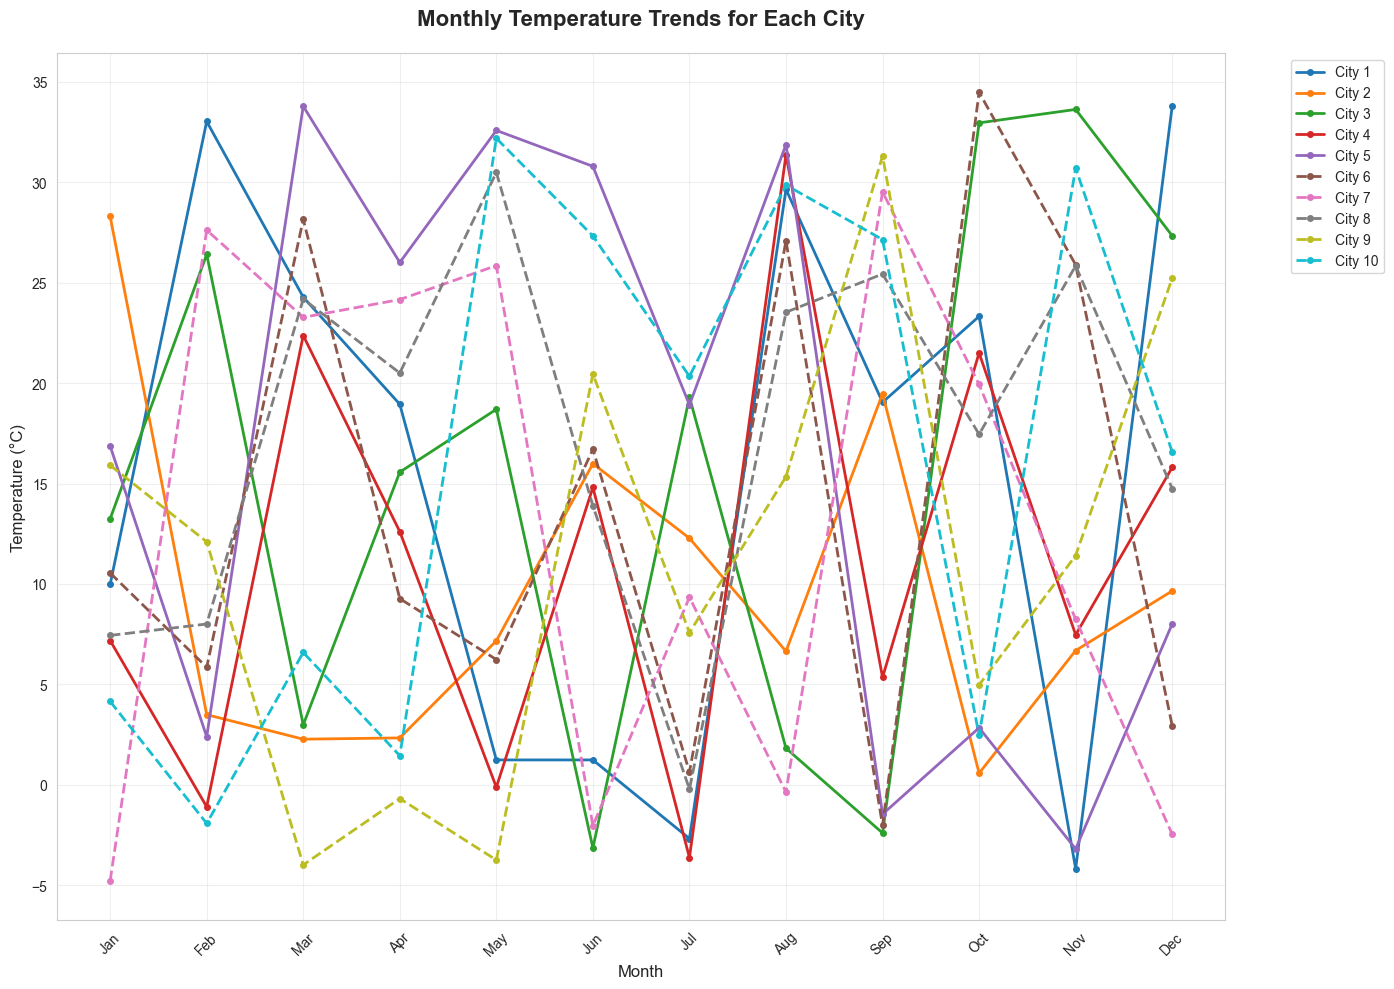

Main visualization: Monthly temperature trends for all cities displayed


In [7]:
# Monthly Temperature Trends for Each City
plt.figure(figsize=(14, 10))

# Creating line plot for each city 
colors = plt.cm.tab10(np.linspace(0, 1, n_cities))

for i, city in enumerate(temperature_df.index):
    linestyle = '--' if i >= 5 else '-'
    plt.plot(temperature_df.columns, temperature_df.loc[city], 
             label=city, color=colors[i], linewidth=2, 
             linestyle=linestyle, marker='o', markersize=4)

plt.title('Monthly Temperature Trends for Each City', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Main visualization: Monthly temperature trends for all cities displayed")

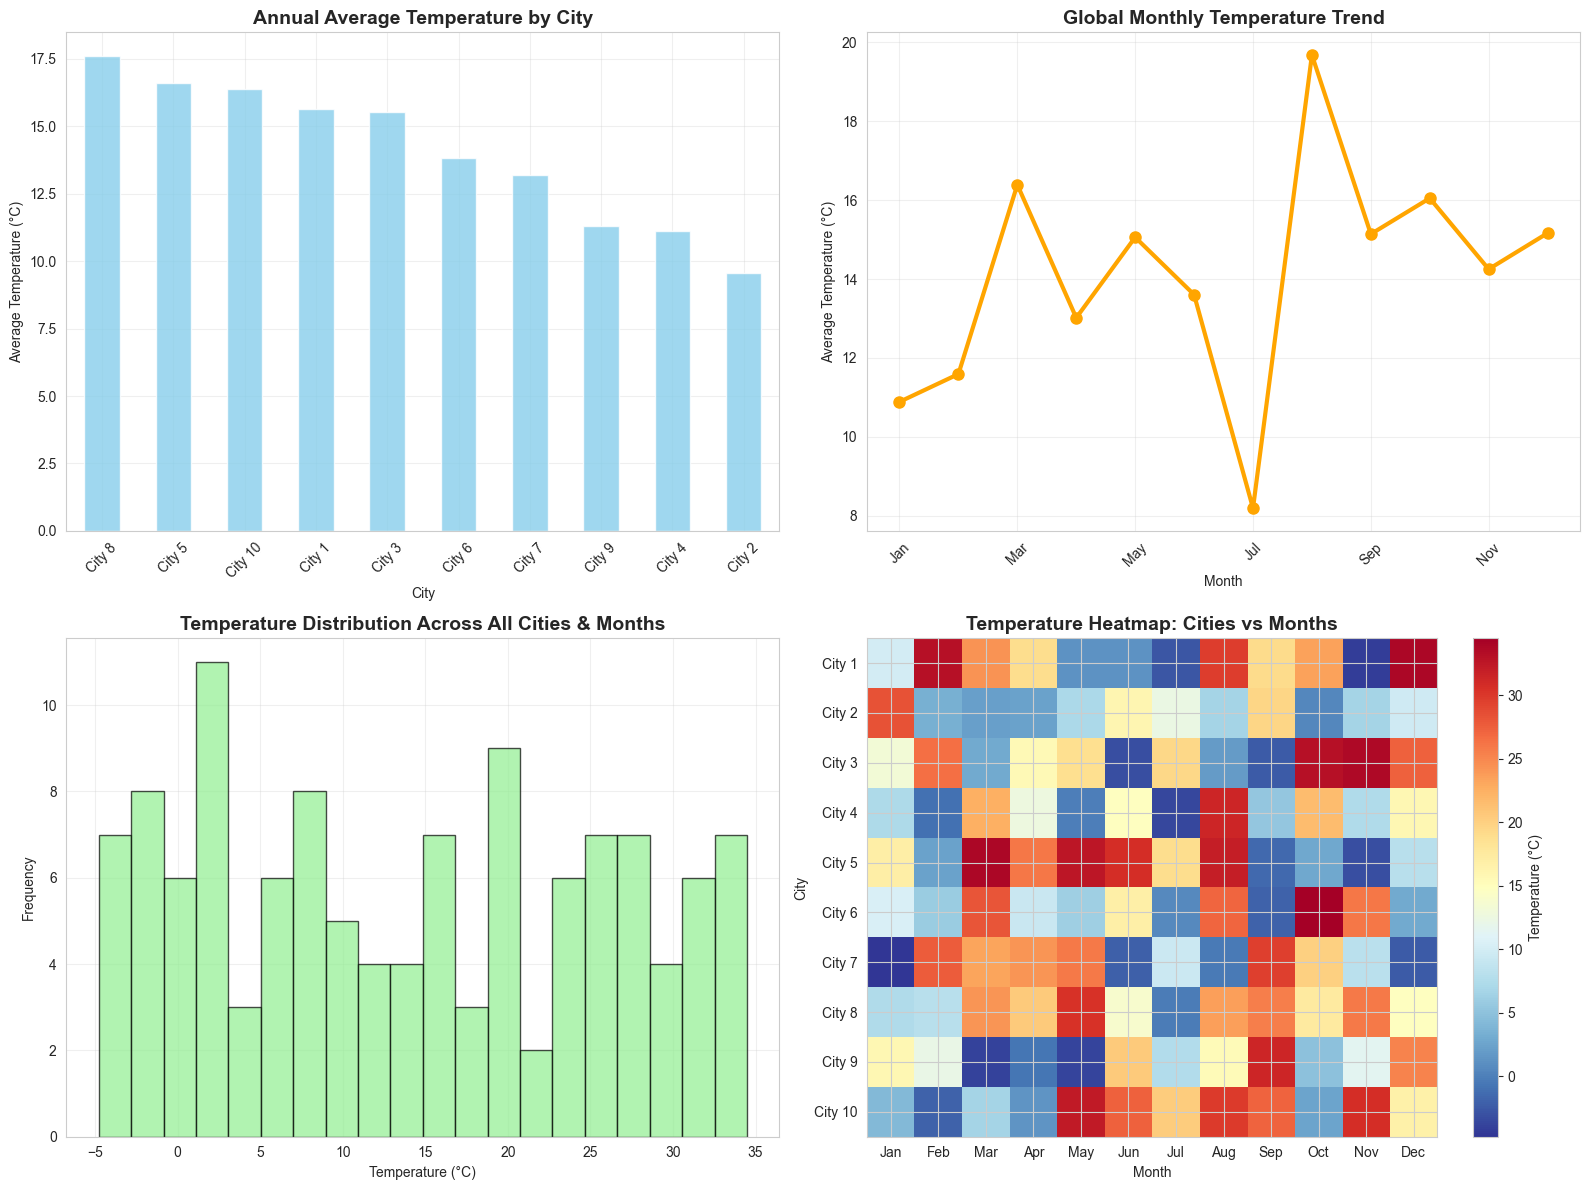

Additional visualizations: Bar chart, line plot, histogram, and heatmap displayed


In [8]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Annual Average Temperature by City (Bar Chart)
annual_avg_sorted.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.8)
ax1.set_title('Annual Average Temperature by City', fontsize=14, fontweight='bold')
ax1.set_xlabel('City')
ax1.set_ylabel('Average Temperature (°C)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Monthly Average Temperature (All Cities Combined)
monthly_avg.plot(kind='line', ax=ax2, marker='o', linewidth=3, markersize=8, color='orange')
ax2.set_title('Global Monthly Temperature Trend', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Average Temperature (°C)')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Temperature Distribution (Histogram)
ax3.hist(temperature_df.values.flatten(), bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
ax3.set_title('Temperature Distribution Across All Cities & Months', fontsize=14, fontweight='bold')
ax3.set_xlabel('Temperature (°C)')
ax3.set_ylabel('Frequency')
ax3.grid(True, alpha=0.3)

# 4. Heatmap of Temperature Data
im = ax4.imshow(temperature_df.values, cmap='RdYlBu_r', aspect='auto')
ax4.set_title('Temperature Heatmap: Cities vs Months', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('City')
ax4.set_xticks(range(len(month_names)))
ax4.set_xticklabels(month_names)
ax4.set_yticks(range(len(city_names)))
ax4.set_yticklabels(city_names)

# Adding colorbar to heatmap
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.show()

print("Additional visualizations: Bar chart, line plot, histogram, and heatmap displayed")

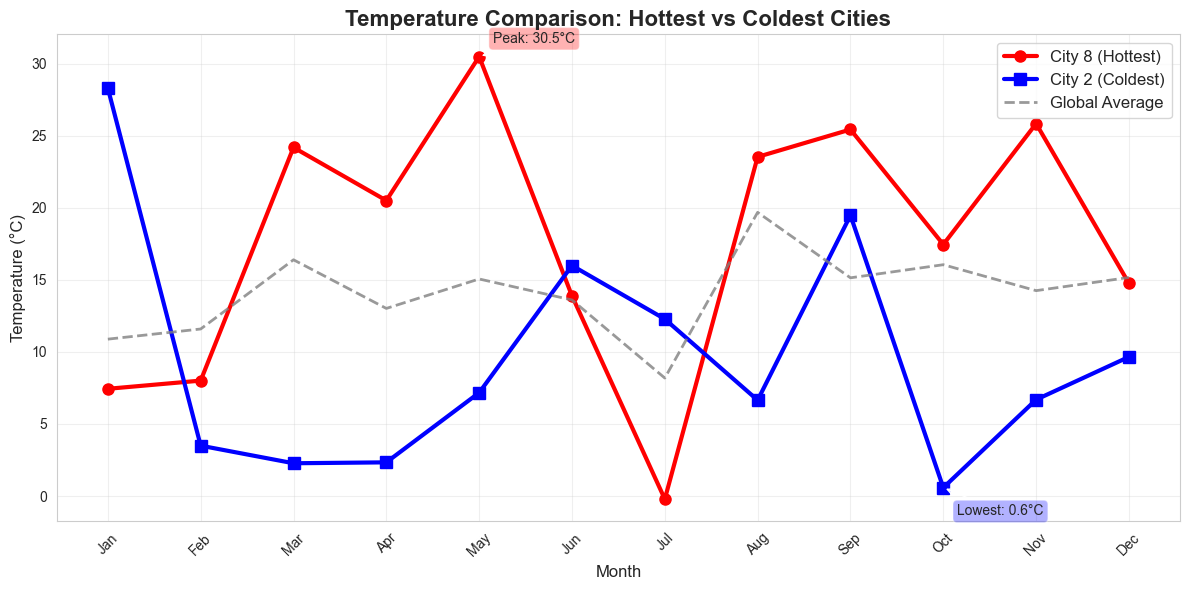

Focus visualization: Comparison between hottest and coldest cities displayed


In [9]:
# Focus visualization: Comparing Hottest vs Coldest Cities
plt.figure(figsize=(12, 6))

# Plotting hottest and coldest cities
plt.plot(temperature_df.columns, temperature_df.loc[hottest_city], 
         label=f'{hottest_city} (Hottest)', marker='o', linewidth=3, 
         color='red', markersize=8)
plt.plot(temperature_df.columns, temperature_df.loc[coldest_city], 
         label=f'{coldest_city} (Coldest)', marker='s', linewidth=3, 
         color='blue', markersize=8)

# Adding overall average line
plt.plot(temperature_df.columns, monthly_avg, 
         label='Global Average', linestyle='--', linewidth=2, 
         color='gray', alpha=0.8)

plt.title('Temperature Comparison: Hottest vs Coldest Cities', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Adding annotations for extreme points
hottest_month_for_hottest = temperature_df.loc[hottest_city].idxmax()
hottest_temp_value = temperature_df.loc[hottest_city].max()
plt.annotate(f'Peak: {hottest_temp_value:.1f}°C', 
             xy=(hottest_month_for_hottest, hottest_temp_value),
             xytext=(10, 10), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.3),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

coldest_month_for_coldest = temperature_df.loc[coldest_city].idxmin()
coldest_temp_value = temperature_df.loc[coldest_city].min()
plt.annotate(f'Lowest: {coldest_temp_value:.1f}°C', 
             xy=(coldest_month_for_coldest, coldest_temp_value),
             xytext=(10, -20), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='blue', alpha=0.3),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print("Focus visualization: Comparison between hottest and coldest cities displayed")

## Summary Report



In [10]:
print("="*60)
print("       GLOBAL TEMPERATURE ANALYSIS SUMMARY REPORT")
print("="*60)

print(f"\nDATA OVERVIEW:")
print(f"  • Dataset size: {n_cities} cities across {n_months} months")
print(f"  • Temperature range: {temperature_df.min().min():.2f}°C to {temperature_df.max().max():.2f}°C")
print(f"  • Total data points: {temperature_df.size}")

print(f"\nKEY FINDINGS:")
print(f"  • Hottest city overall: {hottest_city} ({highest_temp:.2f}°C avg)")
print(f"  • Coldest city overall: {coldest_city} ({lowest_temp:.2f}°C avg)")
print(f"  • Temperature spread: {highest_temp - lowest_temp:.2f}°C difference")
print(f"  • Global average: {annual_avg_temp.mean():.2f}°C")

print(f"\nSEASONAL PATTERNS:")
print(f"  • Warmest month globally: {hottest_month} ({monthly_avg[hottest_month]:.2f}°C)")
print(f"  • Coolest month globally: {coldest_month} ({monthly_avg[coldest_month]:.2f}°C)")
print(f"  • Seasonal variation: {monthly_avg.max() - monthly_avg.min():.2f}°C")

print(f"\nVARIABILITY ANALYSIS:")
most_variable_city = temperature_df.std(axis=1).idxmax()
most_stable_city = temperature_df.std(axis=1).idxmin()
print(f"  • Most variable city: {most_variable_city} (σ = {temperature_df.std(axis=1).max():.2f})")
print(f"  • Most stable city: {most_stable_city} (σ = {temperature_df.std(axis=1).min():.2f})")
print(f"  • Most variable month: {monthly_std.idxmax()} (σ = {monthly_std.max():.2f})")

print(f"\nINTERESTING TRENDS OBSERVED:")
# Finding cities with similar patterns
correlation_matrix = temperature_df.T.corr()
np.fill_diagonal(correlation_matrix.values, np.nan)
most_correlated = correlation_matrix.unstack().idxmax()
highest_correlation = correlation_matrix.max().max()

print(f"  • Cities with most similar patterns: {most_correlated[0]} & {most_correlated[1]}")
print(f"    (Correlation: {highest_correlation:.3f})")

# Temperature extremes
absolute_max = temperature_df.max().max()
absolute_min = temperature_df.min().min()
max_location = temperature_df.stack().idxmax()
min_location = temperature_df.stack().idxmin()

print(f"  • Absolute highest temperature: {absolute_max:.2f}°C ({max_location[0]} in {max_location[1]})")
print(f"  • Absolute lowest temperature: {absolute_min:.2f}°C ({min_location[0]} in {min_location[1]})")

print(f"\nMETHODOLOGY:")
print(f"  • Data generation: NumPy random.uniform(-5, 35)")
print(f"  • Analysis tools: Pandas DataFrame operations")
print(f"  • Visualization: Matplotlib with multiple chart types")
print(f"  • Statistical methods: Mean, std, correlation analysis")

print(f"\nCONCLUSION:")
print(f"  The analysis successfully demonstrates the integration of NumPy,")
print(f"  Pandas, and Matplotlib for comprehensive temperature data analysis.")
print(f"  The synthetic dataset reveals realistic temperature patterns with")
print(f"  significant variation between cities and seasonal fluctuations.")

print("="*60)

       GLOBAL TEMPERATURE ANALYSIS SUMMARY REPORT

DATA OVERVIEW:
  • Dataset size: 10 cities across 12 months
  • Temperature range: -4.78°C to 34.48°C
  • Total data points: 120

KEY FINDINGS:
  • Hottest city overall: City 8 (17.61°C avg)
  • Coldest city overall: City 2 (9.57°C avg)
  • Temperature spread: 8.03°C difference
  • Global average: 14.08°C

SEASONAL PATTERNS:
  • Warmest month globally: Aug (19.68°C)
  • Coolest month globally: Jul (8.19°C)
  • Seasonal variation: 11.50°C

VARIABILITY ANALYSIS:
  • Most variable city: City 5 (σ = 14.34)
  • Most stable city: City 2 (σ = 8.22)
  • Most variable month: May (σ = 14.46)

INTERESTING TRENDS OBSERVED:
  • Cities with most similar patterns: City 4 & City 6
    (Correlation: 0.722)
  • Absolute highest temperature: 34.48°C (City 6 in Oct)
  • Absolute lowest temperature: -4.78°C (City 7 in Jan)

METHODOLOGY:
  • Data generation: NumPy random.uniform(-5, 35)
  • Analysis tools: Pandas DataFrame operations
  • Visualization: Matp